In [158]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from package.RankAMIP.logistic import run_logistic_regression
from package.RankAMIP.data_script import make_BT_design_matrix
from package.RankAMIP.logistic import LogisticAMIP
from package.RankAMIP.logistic import find_closest_matchups
from package.RankAMIP.logistic import isRankingRobust
from package.RankAMIP.data_script import *

### Load Data

In [167]:
# Import datasets from
df = pd.read_csv('/Users/JennyH/Desktop/IsRankingRobust/data/atp_matches_2024.csv')

In [170]:
df_2024_rankings = pd.read_csv('/Users/JennyH/Desktop/IsRankingRobust/data/atp_rankings_current.csv')

In [160]:
# inspect the available splits
df.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2024-0339,Brisbane,Hard,32,A,20240101,300,105777,2.0,NaN,...,58.0,44.0,16.0,11.0,8.0,9.0,14.0,2570.0,8.0,3660.0
1,2024-0339,Brisbane,Hard,32,A,20240101,299,208029,1.0,NaN,...,35.0,31.0,10.0,11.0,5.0,7.0,8.0,3660.0,39.0,1122.0
2,2024-0339,Brisbane,Hard,32,A,20240101,298,105777,2.0,NaN,...,39.0,24.0,14.0,10.0,5.0,7.0,14.0,2570.0,55.0,902.0
3,2024-0339,Brisbane,Hard,32,A,20240101,297,208029,1.0,NaN,...,51.0,31.0,16.0,10.0,3.0,5.0,8.0,3660.0,116.0,573.0
4,2024-0339,Brisbane,Hard,32,A,20240101,296,126128,NaN,NaN,...,37.0,27.0,16.0,10.0,5.0,8.0,39.0,1122.0,44.0,1021.0


In [176]:
top_10_ranked_playerids

0    104925
1    207989
2    106421
3    206173
4    126094
5    126774
6    100644
7    208029
8    128034
9    126203
Name: player, dtype: int64

In [173]:
top_10_ranked_playerids = df_2024_rankings['player'].head(10)

Filter for games between top-ranked players, where both the winner_id and loser_id are in top_10_ranked_playerids.

In [178]:
top_matchups = df[df['winner_id'].isin(top_10_ranked_playerids) & df['loser_id'].isin(top_10_ranked_playerids)]

Notice, there are no columns in this dataframe that tell us which player is player_A or player_B. it only identifies the players by winner/loser.

In [179]:
df.columns

Index(['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level',
       'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry',
       'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age',
       'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand',
       'loser_ht', 'loser_ioc', 'loser_age', 'score', 'best_of', 'round',
       'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon',
       'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt',
       'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced',
       'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points'],
      dtype='object')

There are at least 441 players in the tennis arena.

In [162]:
# number of unique rankings.
df['winner_rank'].nunique(), df['loser_rank'].nunique()

(321, 441)

We will choose to assign player_A and player_B based on alphabetical ordering of name.

In [201]:
rawBT = top_matchups[['winner_name', 'loser_name', 'winner_rank', 'loser_rank']]
rawBT['player_A'] = rawBT.apply(lambda x: min(x['winner_name'], x['loser_name']), axis=1)
rawBT['player_B'] = rawBT.apply(lambda x: max(x['winner_name'], x['loser_name']), axis=1)
rawBT.head()

/var/folders/d0/9cwd6hsd1jx46dktk5_bn85c0000gn/T/ipykernel_7388/3541483567.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rawBT['player_A'] = rawBT.apply(lambda x: min(x['winner_name'], x['loser_name']), axis=1)
/var/folders/d0/9cwd6hsd1jx46dktk5_bn85c0000gn/T/ipykernel_7388/3541483567.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rawBT['player_B'] = rawBT.apply(lambda x: max(x['winner_name'], x['loser_name']), axis=1)


,winner_name,loser_name,winner_rank,loser_rank,player_A,player_B
31,Alexander Zverev,Hubert Hurkacz,7.0,9.0,Alexander Zverev,Hubert Hurkacz
37,Alexander Zverev,Stefanos Tsitsipas,7.0,6.0,Alexander Zverev,Stefanos Tsitsipas
250,Taylor Fritz,Stefanos Tsitsipas,12.0,7.0,Stefanos Tsitsipas,Taylor Fritz
257,Novak Djokovic,Taylor Fritz,1.0,12.0,Novak Djokovic,Taylor Fritz
258,Jannik Sinner,Andrey Rublev,4.0,5.0,Andrey Rublev,Jannik Sinner


In [203]:
rawBT['winner_player_A'] = (rawBT['player_A'] == rawBT['winner_name']).astype(int)
rawBT.head()

/var/folders/d0/9cwd6hsd1jx46dktk5_bn85c0000gn/T/ipykernel_7388/4291864355.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rawBT['winner_player_A'] = (rawBT['player_A'] == rawBT['winner_name']).astype(int)


,winner_name,loser_name,winner_rank,loser_rank,player_A,player_B,winner_player_A
31,Alexander Zverev,Hubert Hurkacz,7.0,9.0,Alexander Zverev,Hubert Hurkacz,1
37,Alexander Zverev,Stefanos Tsitsipas,7.0,6.0,Alexander Zverev,Stefanos Tsitsipas,1
250,Taylor Fritz,Stefanos Tsitsipas,12.0,7.0,Stefanos Tsitsipas,Taylor Fritz,0
257,Novak Djokovic,Taylor Fritz,1.0,12.0,Novak Djokovic,Taylor Fritz,1
258,Jannik Sinner,Andrey Rublev,4.0,5.0,Andrey Rublev,Jannik Sinner,0


In [205]:
# Count wins for each player
win_counts = rawBT['winner_name'].value_counts()
win_counts

Jannik Sinner         15
Carlos Alcaraz        12
Alexander Zverev      10
Taylor Fritz           8
Novak Djokovic         5
Daniil Medvedev        5
Andrey Rublev          3
Stefanos Tsitsipas     2
Holger Rune            1
Hubert Hurkacz         1
Name: winner_name, dtype: int64

Create winner_player_a column.

In [206]:
rawBT.head()

,winner_name,loser_name,winner_rank,loser_rank,player_A,player_B,winner_player_A
31,Alexander Zverev,Hubert Hurkacz,7.0,9.0,Alexander Zverev,Hubert Hurkacz,1
37,Alexander Zverev,Stefanos Tsitsipas,7.0,6.0,Alexander Zverev,Stefanos Tsitsipas,1
250,Taylor Fritz,Stefanos Tsitsipas,12.0,7.0,Stefanos Tsitsipas,Taylor Fritz,0
257,Novak Djokovic,Taylor Fritz,1.0,12.0,Novak Djokovic,Taylor Fritz,1
258,Jannik Sinner,Andrey Rublev,4.0,5.0,Andrey Rublev,Jannik Sinner,0


In [183]:
rawBT['winner_player_a'] = rawBT.apply(lambda x: 1 if x['winner_name'] == x['player_A'] else 0, axis=1)

/var/folders/d0/9cwd6hsd1jx46dktk5_bn85c0000gn/T/ipykernel_7388/1670736560.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rawBT['winner_player_a'] = rawBT.apply(lambda x: 1 if x['winner_name'] == x['player_A'] else 0, axis=1)


In [184]:
for_BT = rawBT[['winner_name', 'loser_name', 'winner_player_a']]
for_BT.head()
# rawBT_noTies.head() # (2575, 3)
# rawBT_noTies.shape

,winner_name,loser_name,winner_player_a
31,Alexander Zverev,Hubert Hurkacz,1
37,Alexander Zverev,Stefanos Tsitsipas,1
250,Taylor Fritz,Stefanos Tsitsipas,0
257,Novak Djokovic,Taylor Fritz,1
258,Jannik Sinner,Andrey Rublev,0


In [193]:
# make the BT design matrix.
X, y, player_to_id = make_BT_design_matrix(for_BT, weight_tie = False)
X.shape, y.shape

((62, 9), (62,))

In [197]:
id_to_player = {v: k for k, v in player_to_id.items()}
id_to_player

{0: 'Alexander Zverev',
 1: 'Taylor Fritz',
 2: 'Novak Djokovic',
 3: 'Jannik Sinner',
 4: 'Daniil Medvedev',
 5: 'Carlos Alcaraz',
 6: 'Holger Rune',
 7: 'Stefanos Tsitsipas',
 8: 'Andrey Rublev',
 9: 'Hubert Hurkacz'}

In [ ]:
# compute BT scores.
model_full = run_logistic_regression(X, y)

# prepend model 0, the reference model, which has score 0.
bt_scores = np.insert(model_full.coef_[0], 0, 0)

In [196]:
bt_scores

array([  0.        , -82.12220761, -61.23564633, -51.4392884 ,
       -30.95002684, -18.91436411, -41.40094491, -71.81281084,
        -8.817515  , -41.49154773])

In [207]:
# combine bt_scores with player names
bt_scores_with_names = {id_to_player[i]: score for i, score in enumerate(bt_scores)}
dict(sorted(bt_scores_with_names.items(), key=lambda x: x[1], reverse=True))


{'Alexander Zverev': 0.0,
 'Andrey Rublev': -8.817514996314737,
 'Carlos Alcaraz': -18.914364109572375,
 'Daniil Medvedev': -30.950026838092104,
 'Holger Rune': -41.400944912980094,
 'Hubert Hurkacz': -41.49154772797846,
 'Jannik Sinner': -51.43928840173429,
 'Novak Djokovic': -61.235646325313716,
 'Stefanos Tsitsipas': -71.8128108421883,
 'Taylor Fritz': -82.12220761137579}

If we run a plain BT-model on the full data, Djokovic does not rank in the top spot.
When we count the wins on the restricted arena (restricted to games between top 10 players) Djokovic also does not come out with the most wins.

In [208]:
# Count wins for each player
win_counts = rawBT['winner_name'].value_counts()
win_counts

Jannik Sinner         15
Carlos Alcaraz        12
Alexander Zverev      10
Taylor Fritz           8
Novak Djokovic         5
Daniil Medvedev        5
Andrey Rublev          3
Stefanos Tsitsipas     2
Holger Rune            1
Hubert Hurkacz         1
Name: winner_name, dtype: int64

# Old Code.

Filter for the most-frequently appearing players so that the matrix is nonsingular.

In [150]:
# Get top players by match count
top_players = pd.concat([for_BT['winner_name'], for_BT['loser_name']]).value_counts().head(20).index

# Filter matches where both players are in top most frequently-appearing players.
top_player_matches = for_BT[for_BT['winner_name'].isin(top_players) & for_BT['loser_name'].isin(top_players)]

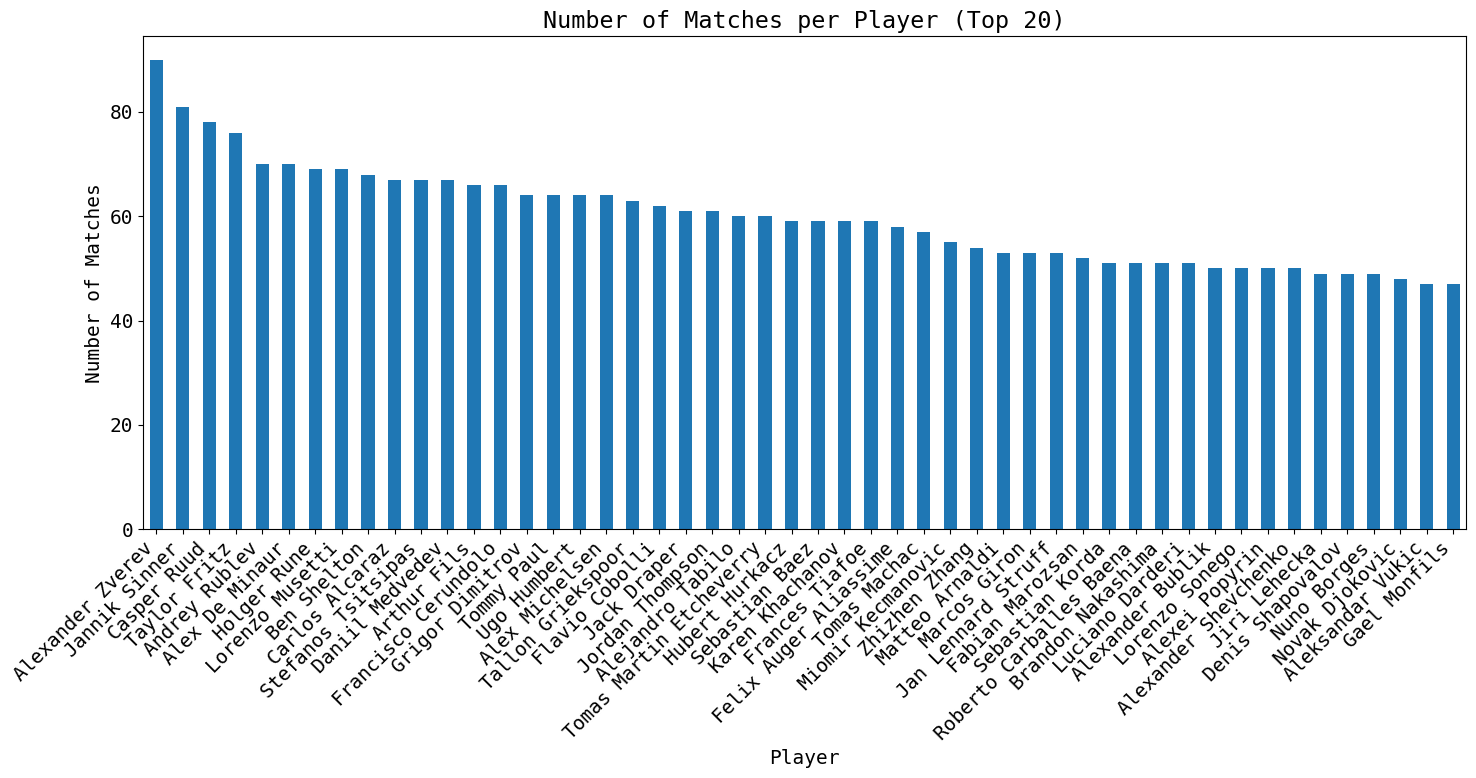

In [137]:
# Count appearances for each player
player_counts = pd.concat([for_BT['winner_name'], for_BT['loser_name']]).value_counts()

# Plot bar chart
plt.figure(figsize=(15,8))
player_counts.head(50).plot(kind='bar')
plt.xticks(rotation=45, ha='right')
plt.title('Number of Matches per Player (Top 20)')
plt.xlabel('Player')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()

In [148]:
# Count players with exactly 1 match
single_match_players = player_counts[player_counts == 1]
print(f"Number of players with only 1 match: {len(single_match_players)}")

Number of players with only 1 match: 120


In [185]:
# make the BT design matrix.
X, y, player_to_id = make_BT_design_matrix(for_BT, weight_tie = False) # ((3076, 442), (3076,))
X.shape, y.shape

((62, 9), (62,))

In [118]:
import pickle
with open('tennis_data.pkl', 'wb') as f:
    pickle.dump((X, y), f)

#### Run Top-k Robustness Check.

In [187]:
ks = [1, 5]
results = {}
for k in ks:
    alphaN = 1
    chatbotA = -1
    while chatbotA == -1:
        chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatIndices = isRankingRobust(k, alphaN, X, y, weighted = False)
        results[(k, alphaN)] = (chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatIndices)
        alphaN += 1

In [188]:
# find the (k, alpha N) pairs that are non-robust.
results_nonrobust = {k: v for k, v in results.items() if v[0] != -1}
results_nonrobust

{(1, 1): (7, None, -8.817514996314737, 16.059445162022868, array([60])),
 (5, 1): (5, 8, 0.09060281499836265, -2.809618987505246, array([17]))}

Restricting the arena to the top 10 players, we only need to drop 3 out of 67 matches.

In [189]:
from package.RankAMIP.plot_util import *
rankings = return_rankings_list(X, y, results, 1, 1, player_to_id)

In [190]:
# plot the rankings on the original arena
filename_to_save = 'fig/tennis3.png'
plot_title = 'Player Rankings in Tennis'
plot_bt_scores(X, y, rankings, alphaN, 10, plot_title, filename_to_save)